# Learn Multiclass Classification


## Multi-class Image Classification
We've just been through a bunch of the following steps with a binary classification problem (pizza vs. steak) and now we're going to step things up a notch with 10 classes of food (multi-class classification).
1. Become one with the data
2. Preprocess the data (get it ready for a model)
3. Create a model (start with a baseline)
4. Fit the model (overfit it to make sure it works)
5. Evaluate the model
6. Adjust different hyperparameters and improve the model (try to beat baseline/reduce overfitting)
7. Repeat until satisfied

In [1]:
# Import libraries
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import zipfile
import seaborn

2025-06-15 13:00:58.968807: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-15 13:00:59.242143: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1749967259.360748     642 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1749967259.383372     642 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1749967259.593040     642 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [ ]:
# !wget https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_all_data.zip

In [2]:
import os
for dirpath, dirnames, filenames in os.walk('10_food_classes_all_data'):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}")

There are 2 directories and 0 images in '10_food_classes_all_data
There are 10 directories and 0 images in '10_food_classes_all_data/test
There are 0 directories and 250 images in '10_food_classes_all_data/test/chicken_curry
There are 0 directories and 250 images in '10_food_classes_all_data/test/chicken_wings
There are 0 directories and 250 images in '10_food_classes_all_data/test/fried_rice
There are 0 directories and 250 images in '10_food_classes_all_data/test/grilled_salmon
There are 0 directories and 250 images in '10_food_classes_all_data/test/hamburger
There are 0 directories and 250 images in '10_food_classes_all_data/test/ice_cream
There are 0 directories and 250 images in '10_food_classes_all_data/test/pizza
There are 0 directories and 250 images in '10_food_classes_all_data/test/ramen
There are 0 directories and 250 images in '10_food_classes_all_data/test/steak
There are 0 directories and 250 images in '10_food_classes_all_data/test/sushi
There are 10 directories and 0 ima

In [5]:
!ls -la 10_food_classes_all_data/

total 16
drwxrwxr-x  4 dikhangcshcmut dikhangcshcmut 4096 Thg 6  11 14:52 .
drwxrwxr-x  7 dikhangcshcmut dikhangcshcmut 4096 Thg 6  11 14:52 ..
drwxrwxr-x 12 dikhangcshcmut dikhangcshcmut 4096 Thg 6  11 14:52 test
drwxrwxr-x 12 dikhangcshcmut dikhangcshcmut 4096 Thg 6  11 14:52 train


In [3]:
# Setup the train and test directories
train_dir = "10_food_classes_all_data/train/"
test_dir = "10_food_classes_all_data/test/"

In [4]:
import pathlib
data_dir = pathlib.Path(train_dir)
class_names = np.array(sorted([item.name for item in data_dir.glob('*')]))
print(class_names)

['chicken_curry' 'chicken_wings' 'fried_rice' 'grilled_salmon' 'hamburger'
 'ice_cream' 'pizza' 'ramen' 'steak' 'sushi']


In [ ]:
from helper_function import plot_loss_curves

In [12]:
# Visualize, visualize, visualize
import random
img = view_random_image(target_dir = train_dir,
                        target_class = random.choice(class_names))


NameError: name 'view_random_image' is not defined

## Preprocessing images (prepare for training the model)


In [13]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Rescale
train_datagen = ImageDataGenerator(rescale=1/255.)
test_datagen = ImageDataGenerator(rescale=1/255.)

# Load data in from directories and turn it into batches
train_data = train_datagen.flow_from_directory(train_dir,
                                               target_size=(224,224),
                                               batch_size=32,
                                               class_mode="categorical")

test_data = test_datagen.flow_from_directory(test_dir,
                                             target_size=(224,224),
                                             batch_size=32,
                                             class_mode="categorical")

Found 7500 images belonging to 10 classes.
Found 2500 images belonging to 10 classes.


### Create model (baseline model)


In [14]:
# Import layers, optimizer,...
from tensorflow.keras.layers import Dense, MaxPool2D, Conv2D, Activation, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import Sequential

In [15]:
model_1 = Sequential([
    Conv2D(filters=10, kernel_size=3, input_shape=(224,224,3)),
    Activation(activation='relu'),
    Conv2D(filters=10, kernel_size=3, activation='relu'),
    MaxPool2D(),
    Conv2D(filters=10, kernel_size=3, activation='relu'),
    Conv2D(filters=10, kernel_size=3, activation='relu'),
    MaxPool2D(),
    Flatten(),
    Dense(10, activation='softmax')
])
model_1.compile(loss=tf.keras.losses.CategoricalCrossentropy(),
                optimizer=Adam(),
                metrics=["accuracy"])

/home/dikhang_hcmut/miniconda3/envs/tf/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1749967492.186519     642 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3539 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [16]:
history_1 = model_1.fit(train_data,
            steps_per_epoch=len(train_data),
            validation_data=test_data,
            validation_steps=len(test_data),
            epochs=5,
            verbose=1)

/home/dikhang_hcmut/miniconda3/envs/tf/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5


I0000 00:00:1749967501.664579    1631 service.cc:152] XLA service 0x7f67dc004db0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1749967501.664614    1631 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9
2025-06-15 13:05:01.719764: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1749967502.039706    1631 cuda_dnn.cc:529] Loaded cuDNN version 90300


  1/235 ━━━━━━━━━━━━━━━━━━━━ 37:16 10s/step - accuracy: 0.0938 - loss: 2.3458

I0000 00:00:1749967509.403672    1631 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


235/235 ━━━━━━━━━━━━━━━━━━━━ 143s 571ms/step - accuracy: 0.1548 - loss: 2.2638 - val_accuracy: 0.2284 - val_loss: 2.1134
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 48s 204ms/step - accuracy: 0.2873 - loss: 1.9990 - val_accuracy: 0.2672 - val_loss: 2.0343
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 50s 212ms/step - accuracy: 0.4570 - loss: 1.6156 - val_accuracy: 0.2560 - val_loss: 2.2401
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 50s 211ms/step - accuracy: 0.6778 - loss: 0.9903 - val_accuracy: 0.2492 - val_loss: 2.7441
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 75s 182ms/step - accuracy: 0.8616 - loss: 0.4632 - val_accuracy: 0.2216 - val_loss: 4.2019


In [17]:
# Evaluate on the test data
model_1.evaluate(test_data)

79/79 ━━━━━━━━━━━━━━━━━━━━ 12s 149ms/step - accuracy: 0.2250 - loss: 4.2850


[4.20188570022583, 0.2215999960899353]

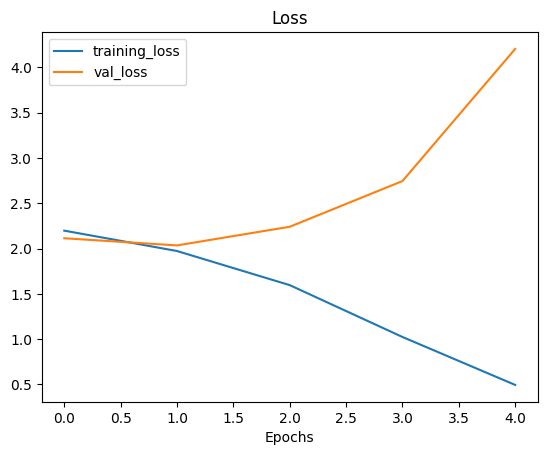

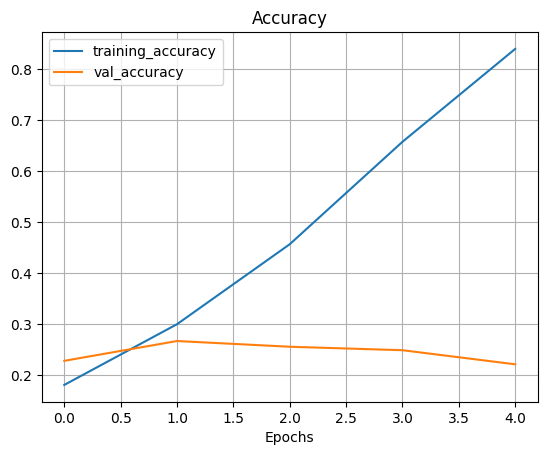

In [18]:
plot_loss_curves(history_1)

### What do these loss curves tell us?

Well, it seems our model is **overfitting**. The training loss is going down but the validation loss is going up. This means our model is learning the training data too well and not generalizing well to unseen data and performing poorly on the validation set.

In [19]:
model_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 222, 222, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 220, 220, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 110, 110, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 108, 108, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 106, 106, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 53, 53, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 28090)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │       280,910 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 851,762 (3.25 MB)

 Trainable params: 283,920 (1.08 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 567,842 (2.17 MB)

In [20]:
# Now we try to simplify the model
model_2 = Sequential([
    Conv2D(10, 3, activation='relu', input_shape=(224,224,3)),
    MaxPool2D(),
    Conv2D(10, 3, activation='relu'),
    MaxPool2D(),
    Flatten(),
    Dense(10, activation='softmax')
])

model_2.compile(loss=tf.keras.losses.CategoricalCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

model_2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 222, 222, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 111, 111, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 109, 109, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 54, 54, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 29160)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │       291,610 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 292,800 (1.12 MB)

 Trainable params: 292,800 (1.12 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
history_2=model_2.fit(train_data,
            epochs=5,
            steps_per_epoch=len(train_data),
            validation_data=test_data,
            validation_steps=len(test_data),
            verbose=1)

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 52s 209ms/step - accuracy: 0.1994 - loss: 2.1922 - val_accuracy: 0.2996 - val_loss: 1.9634
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 43s 183ms/step - accuracy: 0.3789 - loss: 1.8122 - val_accuracy: 0.3832 - val_loss: 1.8123
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 46s 195ms/step - accuracy: 0.5073 - loss: 1.5151 - val_accuracy: 0.3788 - val_loss: 1.8137
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 48s 203ms/step - accuracy: 0.6204 - loss: 1.2038 - val_accuracy: 0.3576 - val_loss: 1.8949
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 48s 206ms/step - accuracy: 0.7745 - loss: 0.7802 - val_accuracy: 0.3468 - val_loss: 2.1488


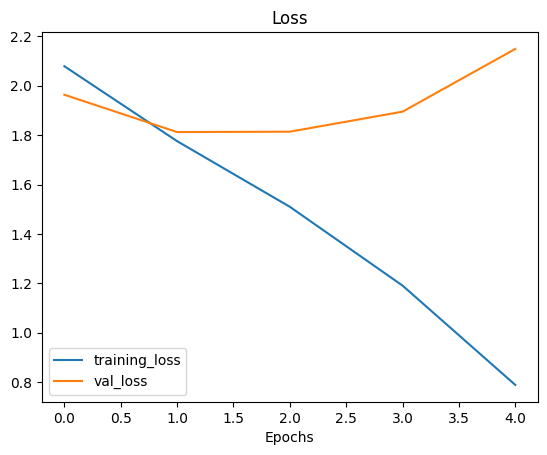

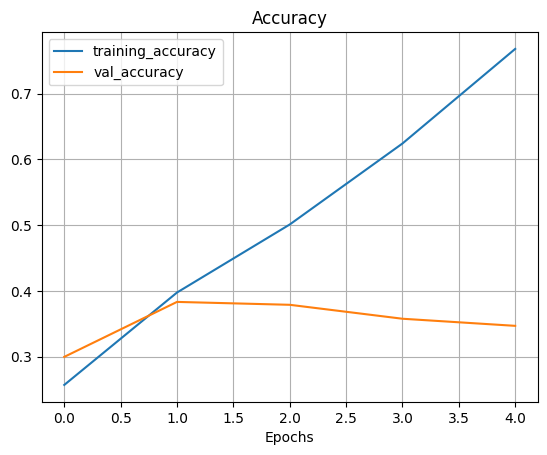

In [22]:
plot_loss_curves(history_2)

### Trying to reduce overfitting with data augmentation

In [23]:
train_datagen_augmented = ImageDataGenerator(rescale=1/255.,
                                             rotation_range=0.2,
                                             width_shift_range=0.2,
                                             height_shift_range=0.2,
                                             zoom_range=0.2,
                                             horizontal_flip=True)

train_data_augmented = train_datagen_augmented.flow_from_directory(train_dir,
                                                                   target_size=(224,224),
                                                                   batch_size=32,
                                                                   class_mode="categorical")

Found 7500 images belonging to 10 classes.


In [24]:
model_augmented = tf.keras.models.clone_model(model_1)

model_augmented.compile(loss=tf.keras.losses.CategoricalCrossentropy(),
                        optimizer=tf.keras.optimizers.Adam(),
                        metrics=["accuracy"])

history_augmented = model_augmented.fit(train_data_augmented,
                        epochs=5,
                        steps_per_epoch=len(train_data_augmented),
                        validation_data=test_data,
                        validation_steps=len(test_data),
                        verbose=1)

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 90s 374ms/step - accuracy: 0.1577 - loss: 2.2436 - val_accuracy: 0.2724 - val_loss: 2.0436
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 87s 369ms/step - accuracy: 0.2722 - loss: 2.0586 - val_accuracy: 0.3248 - val_loss: 1.9243
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 95s 403ms/step - accuracy: 0.2935 - loss: 1.9988 - val_accuracy: 0.3660 - val_loss: 1.8599
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 92s 390ms/step - accuracy: 0.3294 - loss: 1.9542 - val_accuracy: 0.3756 - val_loss: 1.8427
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 87s 369ms/step - accuracy: 0.3336 - loss: 1.9338 - val_accuracy: 0.3820 - val_loss: 1.7861


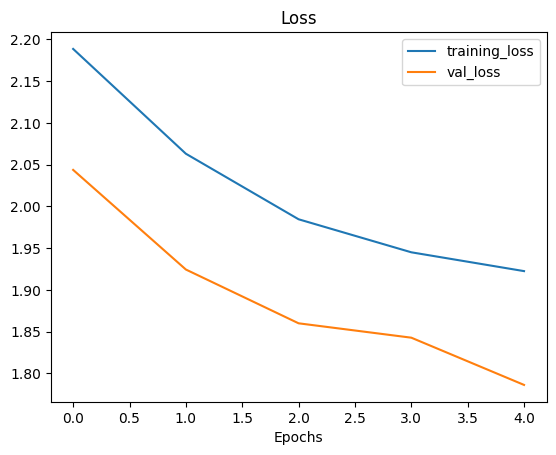

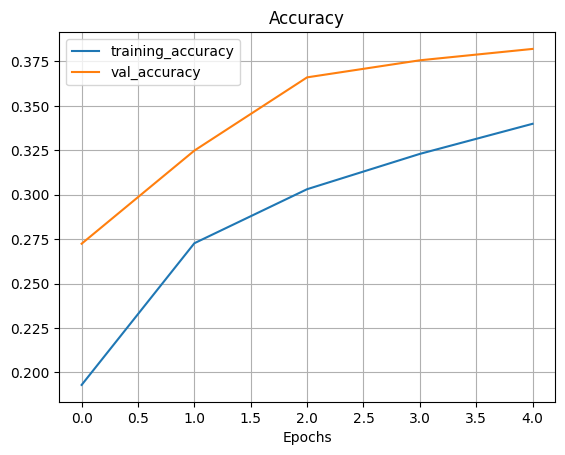

In [25]:
plot_loss_curves(history_augmented)

### Repeat until satisfied

We have to try to bring our loss curves closer together, which means we need to reduce overfitting to improve the validation accuracy.

By running lots of experiments, we can find a model that performs well on the validation set and generalizes better to unseen data.

- **Restructing our model's architecture**: We can try changing the number of layers, the number of neurons in each layer, or the activation functions.

- **Adjusting the learning rate**: We can try different learning rates to see if it helps our model converge better.

- **Apply another data augmentation technique**: We can try different data augmentation techniques to help our model generalize better.

- **Training for longer**: We can try training our model for more epochs to see if it helps improve the validation accuracy.

- **Using transfer learning**: We can use a pre-trained model and fine-tune it for our specific task.


In [26]:
print(train_data_augmented.class_indices)  # Phải in ra 10 class (0→9)
print(train_data_augmented.num_classes)    # Phải = 10



{'chicken_curry': 0, 'chicken_wings': 1, 'fried_rice': 2, 'grilled_salmon': 3, 'hamburger': 4, 'ice_cream': 5, 'pizza': 6, 'ramen': 7, 'steak': 8, 'sushi': 9}
10


In [27]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout, BatchNormalization, Activation

model_fine = Sequential([
    Conv2D(32, 3, input_shape=(224,224,3), padding='same'),
    Activation('relu'),
    
    Conv2D(32, 3, padding='same'),
    Activation('relu'),
    MaxPool2D(),
    
    Conv2D(64, 3, padding='same'),
    Activation('relu'),
    
    Conv2D(64, 3, padding='same'),
    Activation('relu'),
    MaxPool2D(),
    
    Flatten(),
    Dropout(0.3),                   # giảm dropout
    Dense(10, activation='softmax')
])


early_stop = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

model_fine.compile(
    loss=tf.keras.losses.CategoricalCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    metrics=["accuracy"]
)

model_fine.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 200704)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 200704)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │     2,007,050 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,072,618 (7.91 MB)

 Trainable params: 2,072,618 (7.91 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_fine = model_fine.fit(
    train_data_augmented,
    epochs=15,  # tăng từ 5 lên 15
    steps_per_epoch=len(train_data_augmented),
    validation_data=test_data,
    validation_steps=len(test_data),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 375s 2s/step - accuracy: 0.1478 - loss: 2.3239 - val_accuracy: 0.2560 - val_loss: 2.0462
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 340s 1s/step - accuracy: 0.2403 - loss: 2.1153 - val_accuracy: 0.2740 - val_loss: 2.0428
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 337s 1s/step - accuracy: 0.2827 - loss: 2.0579 - val_accuracy: 0.3172 - val_loss: 1.9301
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 311s 1s/step - accuracy: 0.2966 - loss: 2.0065 - val_accuracy: 0.3600 - val_loss: 1.8600
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 308s 1s/step - accuracy: 0.3275 - loss: 1.9459 - val_accuracy: 0.3724 - val_loss: 1.8252


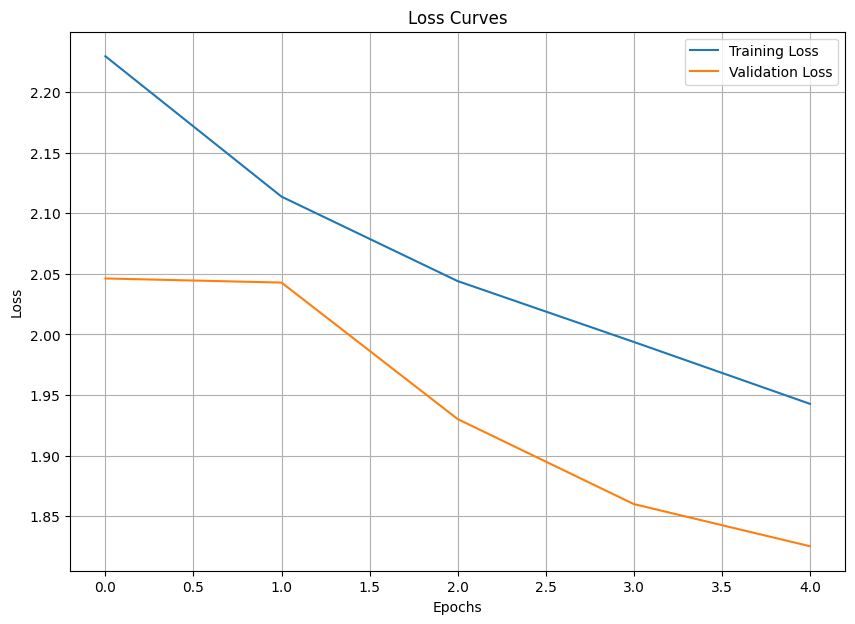

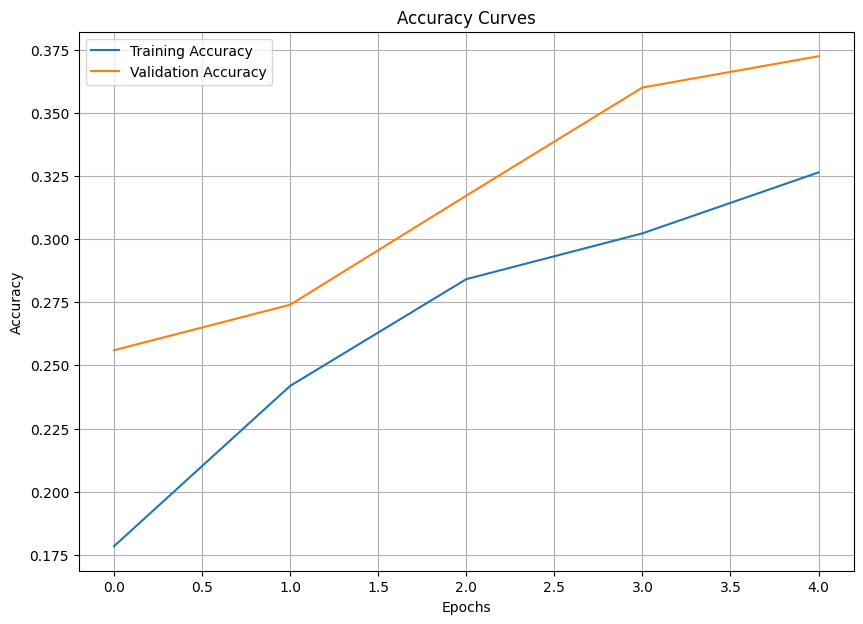

In [96]:
plot_loss_curves(history_fine)

In [28]:
model_refine = Sequential([
    Conv2D(32, 3, input_shape=(224,224,3), padding='same'),
    Activation('relu'),
    
    Conv2D(32, 3, padding='same'),
    Activation('relu'),
    MaxPool2D(),
    
    Conv2D(64, 3, padding='same'),
    Activation('relu'),
    
    Conv2D(64, 3, padding='same'),
    Activation('relu'),
    MaxPool2D(),
    
    Flatten(),
    Dropout(0.3),                   # giảm dropout
    Dense(10, activation='softmax')
])


early_stop = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

model_refine.compile(
    loss=tf.keras.losses.CategoricalCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    metrics=["accuracy"]
)

model_refine.summary()

history_reine = model_refine.fit(
    train_data_augmented,
    epochs=15,  # tăng từ 5 lên 15
    steps_per_epoch=len(train_data_augmented),
    validation_data=test_data,
    validation_steps=len(test_data),
    callbacks=[early_stop],
    verbose=1
)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 200704)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 200704)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │     2,007,050 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,072,618 (7.91 MB)

 Trainable params: 2,072,618 (7.91 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 116s 438ms/step - accuracy: 0.1680 - loss: 2.2234 - val_accuracy: 0.3036 - val_loss: 1.9675
Epoch 2/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 87s 370ms/step - accuracy: 0.2832 - loss: 2.0250 - val_accuracy: 0.3588 - val_loss: 1.8522
Epoch 3/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 90s 383ms/step - accuracy: 0.3280 - loss: 1.9351 - val_accuracy: 0.3804 - val_loss: 1.8181
Epoch 4/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 97s 411ms/step - accuracy: 0.3411 - loss: 1.9140 - val_accuracy: 0.3864 - val_loss: 1.7505
Epoch 5/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 110s 469ms/step - accuracy: 0.3627 - loss: 1.8762 - val_accuracy: 0.4024 - val_loss: 1.7471
Epoch 6/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 103s 436ms/step - accuracy: 0.3740 - loss: 1.8275 - val_accuracy: 0.4428 - val_loss: 1.6826
Epoch 7/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 89s 378ms/step - accuracy: 0.3771 - loss: 1.8141 - val_accuracy: 0.4300 - val_loss: 1.7004
Epoch 8/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 86s 364ms/step - accuracy: 0.3993 - loss

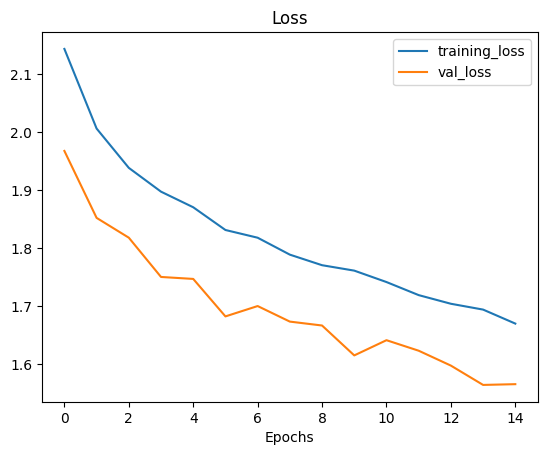

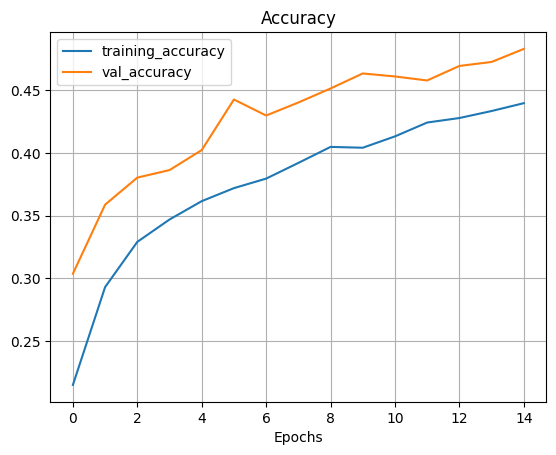

In [29]:
plot_loss_curves(history_reine)

##  Making a prediction with our trained model

/bin/bash: /home/dikhang_hcmut/miniconda3/envs/tf/lib/libtinfo.so.6: no version information available (required by /bin/bash)
--2025-06-15 13:49:48--  https://storage.googleapis.com/ztm_tf_course/food_vision/pizza_steak.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 142.250.76.27, 142.250.198.123, 142.250.71.219, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.250.76.27|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 109540975 (104M) [application/zip]
Saving to: ‘pizza_steak.zip’

pizza_steak.zip     100%[===================>] 104.47M  20.0MB/s    in 6.4s    

2025-06-15 13:49:54 (16.4 MB/s) - ‘pizza_steak.zip’ saved [109540975/109540975]

here're 2 directories and 0 images in 'pizza_steak'
here're 2 directories and 0 images in 'pizza_steak/test'
here're 0 directories and 250 images in 'pizza_steak/test/pizza'
here're 0 directories and 250 images in 'pizza_steak/test/steak'
here're 2 directories and 0 images in 'pizza_st

/home/dikhang_hcmut/miniconda3/envs/tf/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/dikhang_hcmut/miniconda3/envs/tf/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 17s 322ms/step - accuracy: 0.6294 - loss: 0.6457 - val_accuracy: 0.8120 - val_loss: 0.4192
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 10s 208ms/step - accuracy: 0.8131 - loss: 0.4216 - val_accuracy: 0.8720 - val_loss: 0.3489
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 11s 219ms/step - accuracy: 0.8223 - loss: 0.4008 - val_accuracy: 0.8440 - val_loss: 0.3388
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 11s 231ms/step - accuracy: 0.8144 - loss: 0.4225 - val_accuracy: 0.8260 - val_loss: 0.3708
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 11s 225ms/step - accuracy: 0.8481 - loss: 0.3589 - val_accuracy: 0.8460 - val_loss: 0.3380


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 222, 222, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 220, 220, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 110, 110, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 108, 108, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 106, 106, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 53, 53, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 28090)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │        28,091 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

...

 Trainable params: 8,861 (34.61 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 17,724 (69.24 KB)

Found 1500 images belonging to 2 classes.
Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 21s 410ms/step - accuracy: 0.5653 - loss: 0.6798 - val_accuracy: 0.7480 - val_loss: 0.5158
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 19s 401ms/step - accuracy: 0.7507 - loss: 0.5332 - val_accuracy: 0.8040 - val_loss: 0.4256
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 19s 396ms/step - accuracy: 0.7609 - loss: 0.5105 - val_accuracy: 0.7780 - val_loss: 0.4329
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 19s 396ms/step - accuracy: 0.7869 - loss: 0.4621 - val_accuracy: 0.8400 - val_loss: 0.3643
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 19s 394ms/step - accuracy: 0.7869 - loss: 0.4784 - val_accuracy: 0.8340 - val_loss: 0.3787
Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 22s 409ms/step - accuracy: 0.5641 - loss: 0.6805 - val_accuracy: 0.7540 - val_loss: 0.5221
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 19s 409ms/step - accuracy: 0.7235 - loss: 0.5618 - val_accuracy: 0.7760 - val_loss: 0.4497
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 19s 401ms/step - accuracy

['pizza' 'steak']
(4032, 3024, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 713ms/step
Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 22s 428ms/step - accuracy: 0.5580 - loss: 0.7108 - val_accuracy: 0.7060 - val_loss: 0.5350
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 19s 396ms/step - accuracy: 0.7283 - loss: 0.5656 - val_accuracy: 0.8120 - val_loss: 0.4065
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 20s 416ms/step - accuracy: 0.7946 - loss: 0.4785 - val_accuracy: 0.8020 - val_loss: 0.4333
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 20s 422ms/step - accuracy: 0.7500 - loss: 0.5356 - val_accuracy: 0.8640 - val_loss: 0.3654
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 19s 407ms/step - accuracy: 0.7676 - loss: 0.4995 - val_accuracy: 0.8580 - val_loss: 0.3525
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 670ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
[[0.6222661]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━

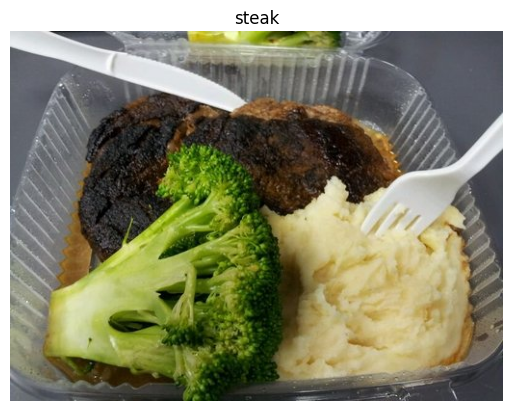

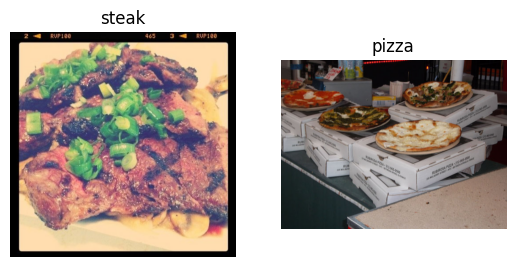

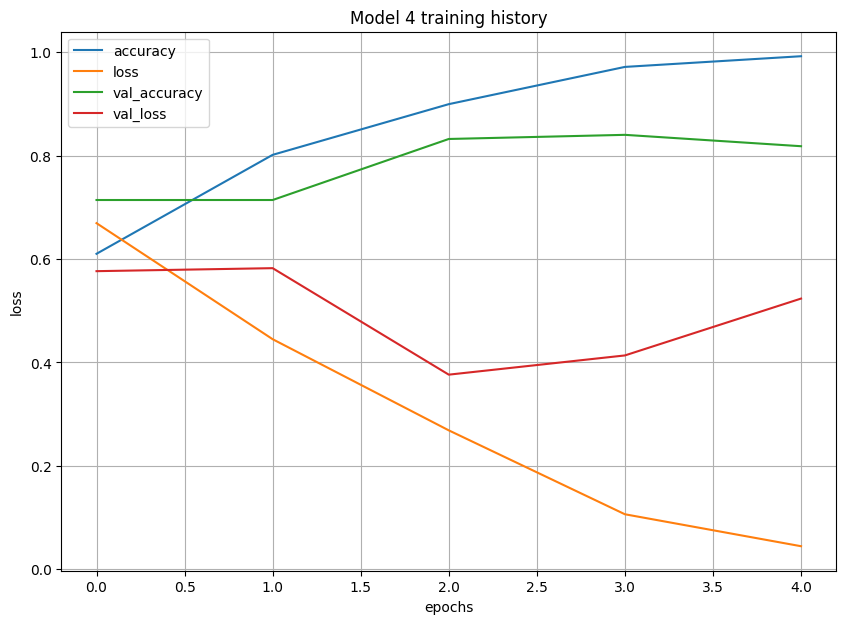

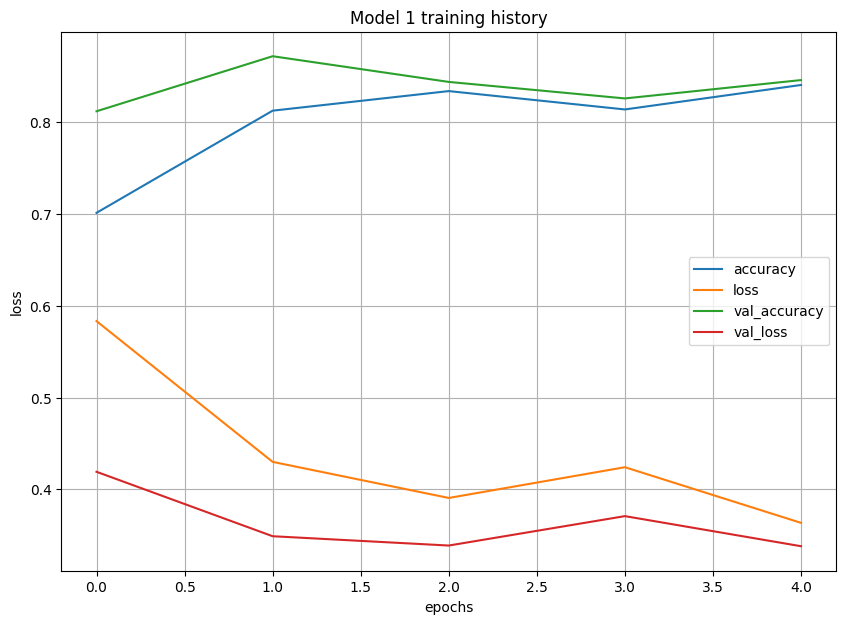

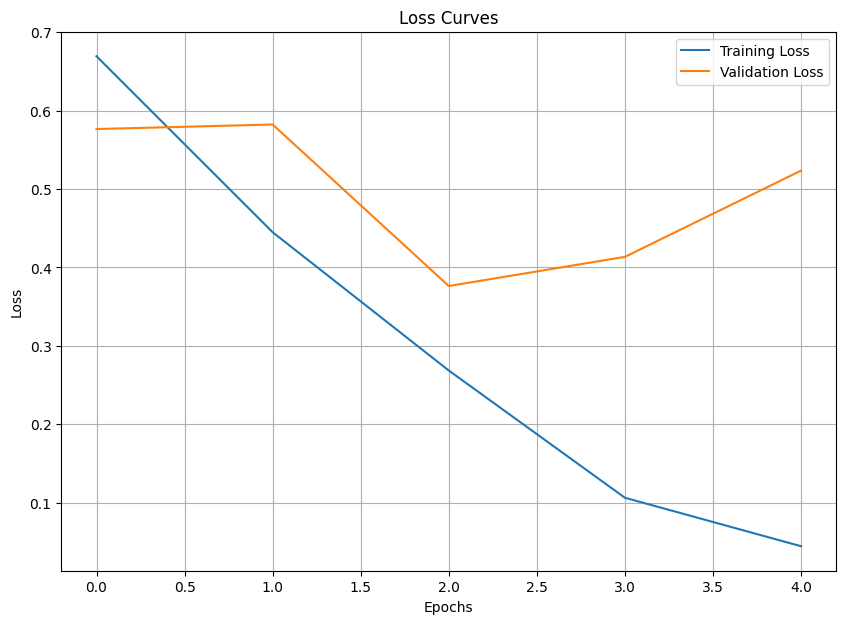

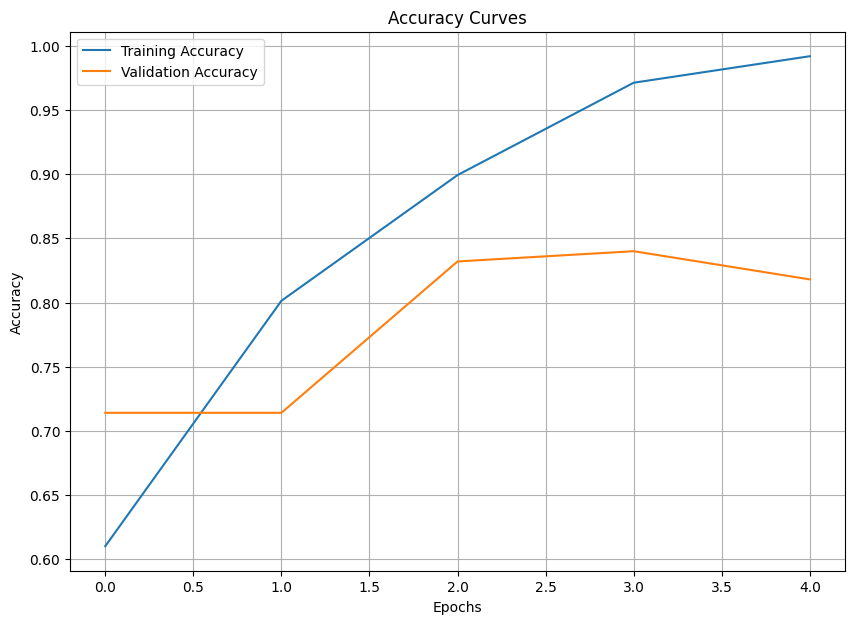

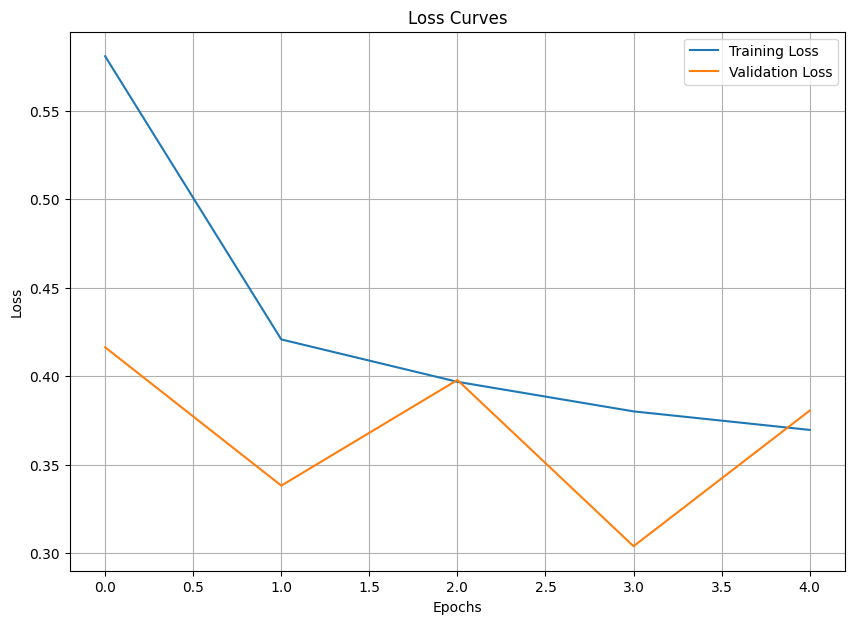

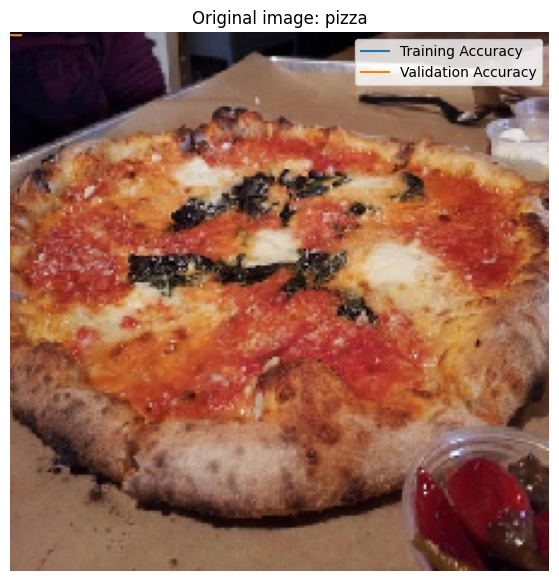

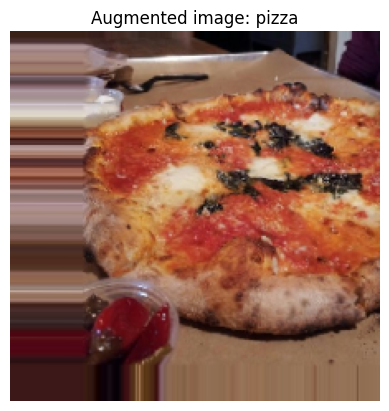

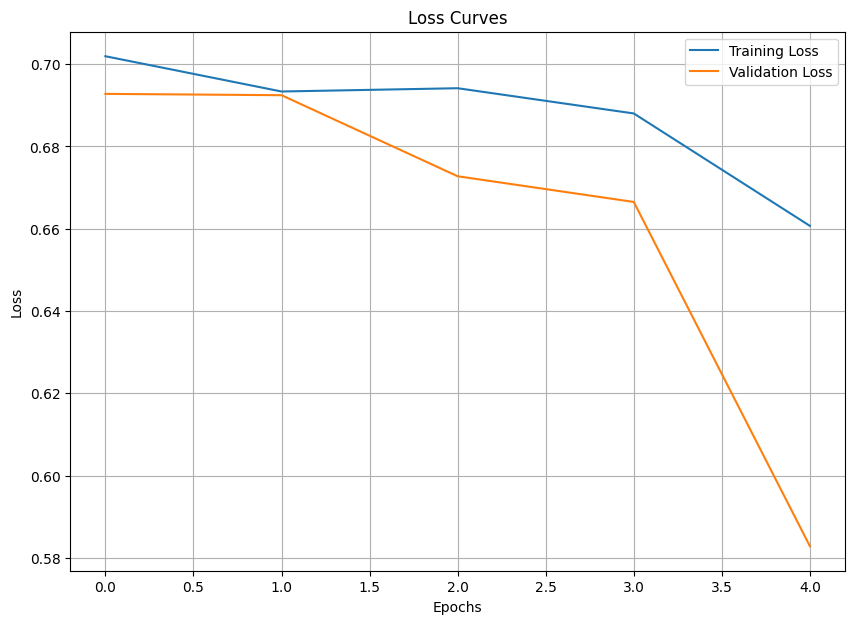

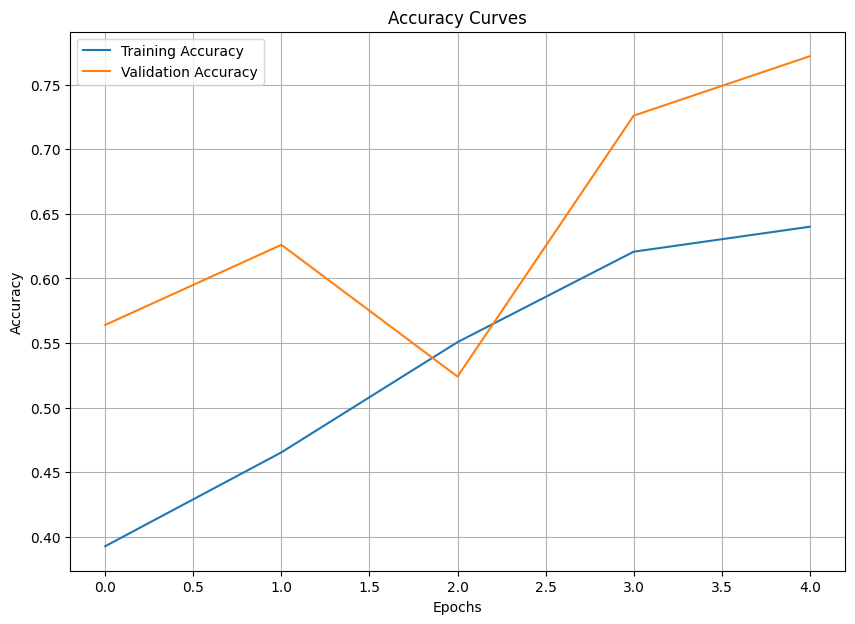

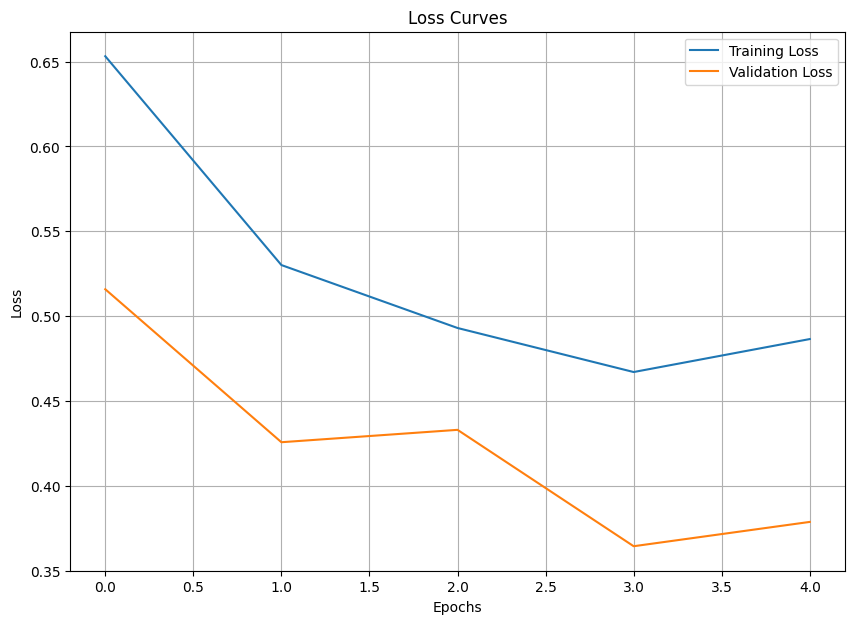

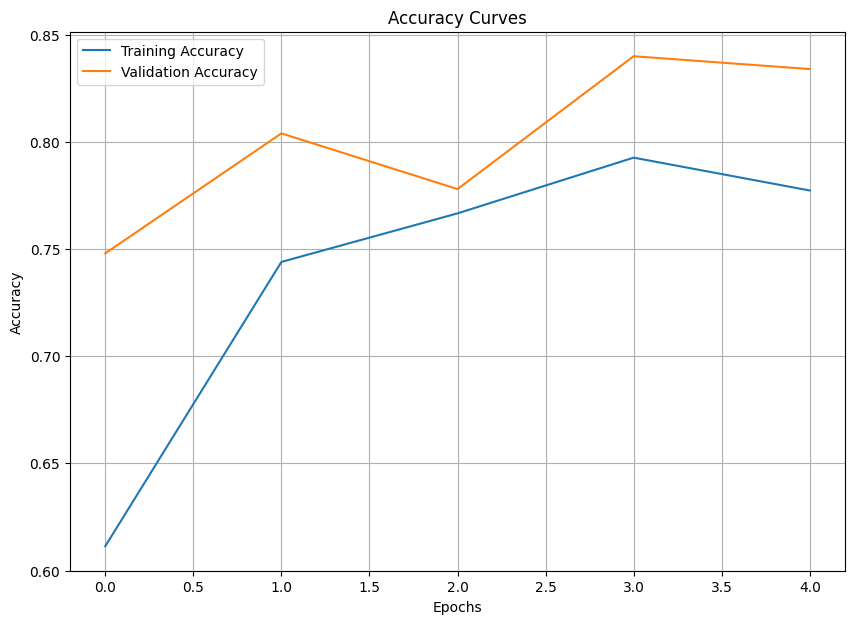

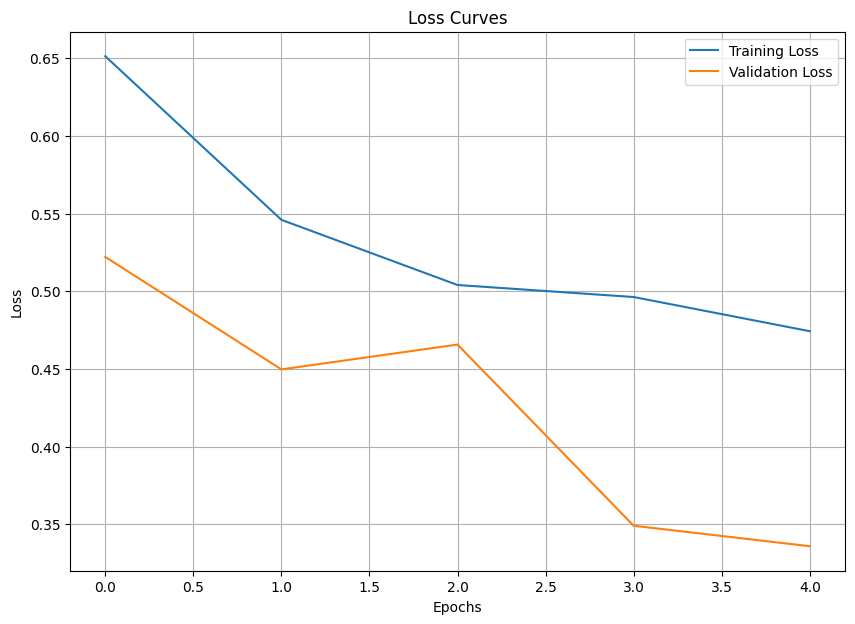

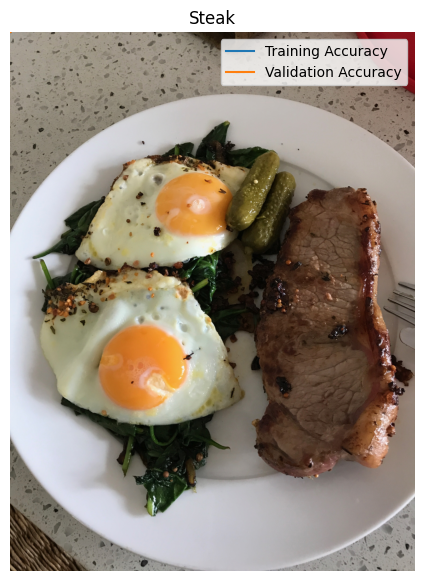

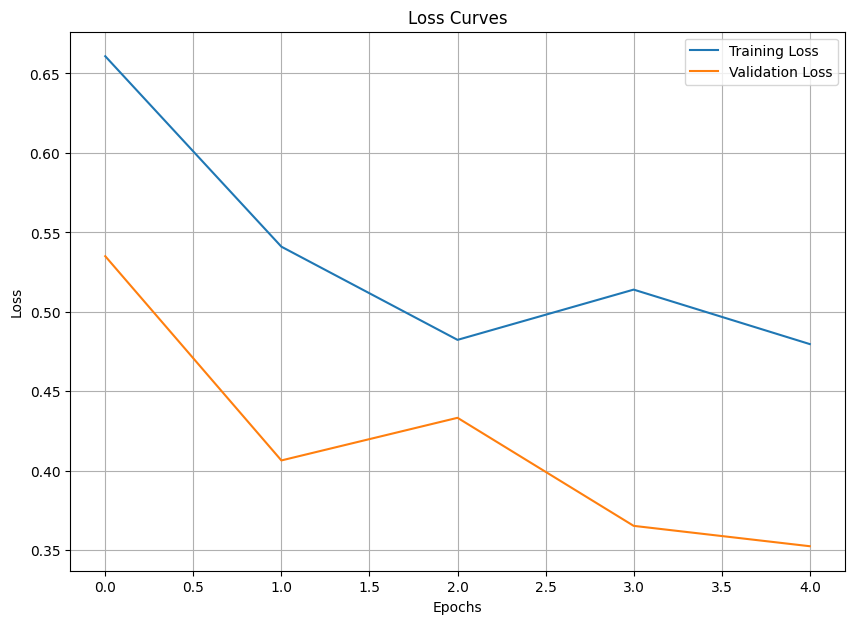

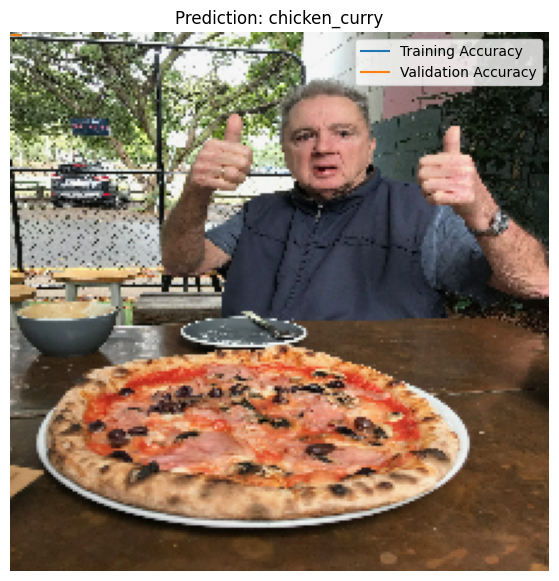

In [36]:
import import_ipynb
from coding_CV import pred_and_plot, load_and_prep_image
pred_and_plot(model_refine, "img/03-pizza-dad.jpeg", class_names)
print(class_names)
print(model_refine.predict(tf.expand_dims(load_and_prep_image("img/03-pizza-dad.jpeg", img_shape=224), axis=0)))

`chicken_curry` again? There must be something wrong...

I think it might have to do with our pred_and_plot function.

Let's makes a prediction without using the function and see where it might be going wrong.

Since our model has a `'softmax'` activation function and 10 output neurons, it outputs a prediction probability for each of the classes in our model.

The class with the **highest probability** is what the model believes the image contains.

We can find the maximum value index using **argmax** and then use that to index our class_names list to output the predicted class.

In [38]:
# Adjust function to work with multi-class
def pred_and_plot_multi(model, filename, class_names):
  """
  Imports an image located at filename, makes a prediction on it with
  a trained model and plots the image with the predicted class as the title.
  """
  # Import the target image and preprocess it
  img = load_and_prep_image(filename)

  # Make a prediction
  pred = model.predict(tf.expand_dims(img, axis=0))

  # Get the predicted class
  if len(pred[0]) > 1: # check for multi-class
    pred_class = class_names[pred.argmax()] # if more than one output, take the max
  else:
    pred_class = class_names[int(tf.round(pred)[0][0])] # if only one output, round

  # Plot the image and predicted class
  plt.imshow(img)
  plt.title(f"Prediction: {pred_class}")
  plt.axis(False);

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
['chicken_curry' 'chicken_wings' 'fried_rice' 'grilled_salmon' 'hamburger'
 'ice_cream' 'pizza' 'ramen' 'steak' 'sushi']
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
[[0.13096833 0.05681719 0.05494333 0.09831896 0.07589434 0.0404486
  0.18321726 0.14243989 0.14169867 0.07525349]]


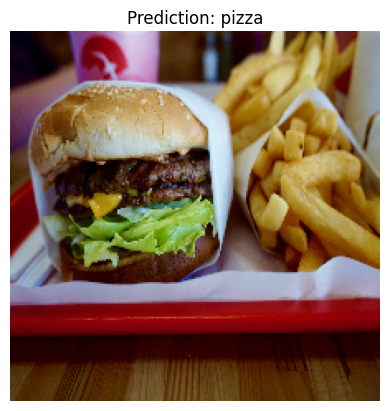

In [43]:
pred_and_plot_multi(model_refine, "img/03-hamburger.jpeg", class_names)
print(class_names)
print(model_refine.predict(tf.expand_dims(load_and_prep_image("img/03-hamburger.jpeg", img_shape=224), axis=0)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
['chicken_curry' 'chicken_wings' 'fried_rice' 'grilled_salmon' 'hamburger'
 'ice_cream' 'pizza' 'ramen' 'steak' 'sushi']
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
[[0.21323243 0.10908179 0.00828149 0.30589336 0.02124885 0.00608509
  0.12544392 0.05950843 0.04258893 0.10863575]]


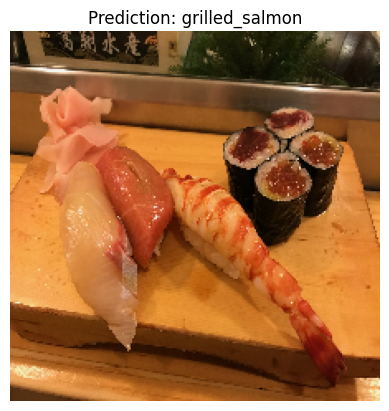

In [42]:
pred_and_plot_multi(model_refine, "img/03-sushi.jpeg", class_names)
print(class_names)
print(model_refine.predict(tf.expand_dims(load_and_prep_image("img/03-sushi.jpeg", img_shape=224), axis=0)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
['chicken_curry' 'chicken_wings' 'fried_rice' 'grilled_salmon' 'hamburger'
 'ice_cream' 'pizza' 'ramen' 'steak' 'sushi']
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
[[2.7446436e-02 1.0050646e-01 2.9223978e-03 3.2381815e-01 5.7914411e-03
  3.7548319e-01 6.0721650e-05 2.1344598e-03 1.3739023e-01 2.4446616e-02]]


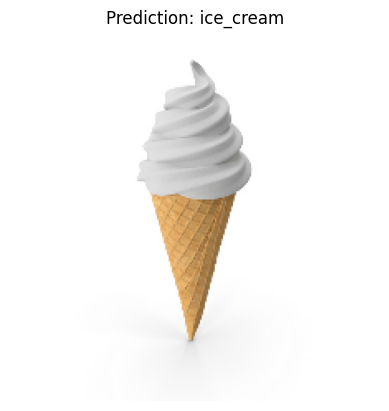

In [41]:
pred_and_plot_multi(model_refine, "img/ice_cream.jpg", class_names)
print(class_names)
print(model_refine.predict(tf.expand_dims(load_and_prep_image("img/ice_cream.jpg", img_shape=224), axis=0)))

## Saving and loading our model

In [122]:
# Saving the best ever model
model_refine.save("saved_trained_model.h5")

In [124]:
loaded_model = tf.keras.models.load_model("saved_trained_model.h5")
loaded_model.predict(test_data)

79/79 ━━━━━━━━━━━━━━━━━━━━ 25s 313ms/step


array([[0.03375101, 0.0232987 , 0.07826614, ..., 0.02208016, 0.01689832,
        0.26141778],
       [0.0197649 , 0.03959696, 0.0265776 , ..., 0.07293013, 0.24671648,
        0.0051687 ],
       [0.05015851, 0.08989096, 0.04674456, ..., 0.02396043, 0.5918165 ,
        0.00164658],
       ...,
       [0.06149883, 0.8010113 , 0.00116179, ..., 0.00211432, 0.03838629,
        0.00244192],
       [0.10649437, 0.04305747, 0.16814664, ..., 0.12600197, 0.0623727 ,
        0.03141889],
       [0.02214034, 0.07511005, 0.01614683, ..., 0.06711628, 0.11478806,
        0.14492247]], dtype=float32)

In [64]:
model_refine_2 = Sequential([
    # Đã có Rescaling bên ngoài rồi

    Conv2D(32, 3, padding='same'), Activation('relu'),
    Conv2D(32, 3, padding='same'), Activation('relu'),
    MaxPool2D(),

    Conv2D(64, 3, padding='same'), Activation('relu'),
    Conv2D(64, 3, padding='same'), Activation('relu'),
    MaxPool2D(),

    Conv2D(128, 3, padding='same'), Activation('relu'),
    MaxPool2D(),

    Flatten(),
    Dropout(0.4),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(10, activation='softmax')
])

In [62]:
model_refine_2.summary()

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_57 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_29 (Activation)      │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_58 (Conv2D)              │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_30 (Activation)      │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_36 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_59 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_31 (Activation)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_60 (Conv2D)              │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_32 (Activation)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_37 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_61 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_33 (Activation)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_38 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_17 (Flatten)            │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,985,898 (49.54 MB)

 Trainable params: 12,985,898 (49.54 MB)

 Non-trainable params: 0 (0.00 B)

In [65]:
model_refine_2.compile(
    loss="categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(1e-4),
    metrics=["accuracy"]
)
lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=2, verbose=1
)

checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    "best_model.h5", save_best_only=True, monitor="val_accuracy", mode="max"
)

history_refine_2 = model_refine_2.fit(
    train_data_augmented,
    epochs=10,
    validation_data=test_data,
    callbacks=[early_stop, lr_scheduler, checkpoint_cb]
)


Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step - accuracy: 0.1539 - loss: 2.2598

235/235 ━━━━━━━━━━━━━━━━━━━━ 111s 458ms/step - accuracy: 0.1540 - loss: 2.2596 - val_accuracy: 0.2288 - val_loss: 2.0952 - learning_rate: 1.0000e-04
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 387ms/step - accuracy: 0.2203 - loss: 2.1363

235/235 ━━━━━━━━━━━━━━━━━━━━ 108s 456ms/step - accuracy: 0.2204 - loss: 2.1362 - val_accuracy: 0.3044 - val_loss: 1.9714 - learning_rate: 1.0000e-04
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step - accuracy: 0.2643 - loss: 2.0477

235/235 ━━━━━━━━━━━━━━━━━━━━ 107s 452ms/step - accuracy: 0.2644 - loss: 2.0476 - val_accuracy: 0.3544 - val_loss: 1.8858 - learning_rate: 1.0000e-04
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 364ms/step - accuracy: 0.3084 - loss: 1.9681

235/235 ━━━━━━━━━━━━━━━━━━━━ 102s 430ms/step - accuracy: 0.3084 - loss: 1.9682 - val_accuracy: 0.3584 - val_loss: 1.8698 - learning_rate: 1.0000e-04
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 363ms/step - accuracy: 0.3179 - loss: 1.9392

235/235 ━━━━━━━━━━━━━━━━━━━━ 101s 429ms/step - accuracy: 0.3179 - loss: 1.9392 - val_accuracy: 0.3772 - val_loss: 1.8296 - learning_rate: 1.0000e-04
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 378ms/step - accuracy: 0.3382 - loss: 1.9007

235/235 ━━━━━━━━━━━━━━━━━━━━ 104s 443ms/step - accuracy: 0.3382 - loss: 1.9008 - val_accuracy: 0.4096 - val_loss: 1.7486 - learning_rate: 1.0000e-04
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 98s 416ms/step - accuracy: 0.3447 - loss: 1.8872 - val_accuracy: 0.4036 - val_loss: 1.7435 - learning_rate: 1.0000e-04
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step - accuracy: 0.3603 - loss: 1.8430

235/235 ━━━━━━━━━━━━━━━━━━━━ 85s 363ms/step - accuracy: 0.3603 - loss: 1.8429 - val_accuracy: 0.4520 - val_loss: 1.6322 - learning_rate: 1.0000e-04
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 85s 362ms/step - accuracy: 0.3688 - loss: 1.8373 - val_accuracy: 0.4468 - val_loss: 1.6597 - learning_rate: 1.0000e-04
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step - accuracy: 0.3814 - loss: 1.8215
Epoch 10: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
235/235 ━━━━━━━━━━━━━━━━━━━━ 86s 367ms/step - accuracy: 0.3814 - loss: 1.8214 - val_accuracy: 0.4264 - val_loss: 1.6980 - learning_rate: 1.0000e-04


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
['chicken_curry' 'chicken_wings' 'fried_rice' 'grilled_salmon' 'hamburger'
 'ice_cream' 'pizza' 'ramen' 'steak' 'sushi']
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
[[0.3686208  0.02189164 0.27458602 0.01771919 0.05875799 0.02097965
  0.019533   0.18627305 0.00404992 0.02758876]]


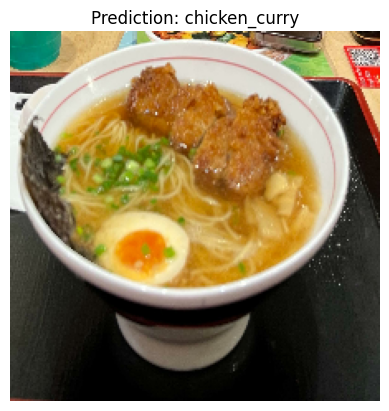

In [66]:
pred_and_plot_multi(model_refine, "img/ramen.jpeg", class_names)
print(class_names)
print(model_refine.predict(tf.expand_dims(load_and_prep_image("img/ramen.jpeg", img_shape=224), axis=0)))